In [1]:
# =========================================
# Import required libraries
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import math

In [2]:
# =========================================
# Load CSV dataset
# =========================================

data_path = "../data"

df = pd.read_csv(f"{data_path}/Breast Cancer Wisconsin.csv")

print(df.head())
df.info()

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [10]:
# =========================================
# Define Target (y)
# =========================================

y = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

# Confirm that conversion worked
print(y.value_counts(dropna=False))

diagnosis
0    357
1    212
Name: count, dtype: int64


In [11]:
# =========================================
# Define Features (X)
# =========================================

selected_features = ["radius_mean", "texture_mean"]

X = df[selected_features]

print(X.head())

   radius_mean  texture_mean
0        17.99         10.38
1        20.57         17.77
2        19.69         21.25
3        11.42         20.38
4        20.29         14.34


In [12]:
# =========================================
# Confirm Shapes
# =========================================

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 2)
y shape: (569,)


In [13]:
# =========================================
# Train/Test Split
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# =========================================
# Convert to NumPy
# =========================================

X_train_np = X_train.to_numpy(dtype=float)
X_test_np = X_test.to_numpy(dtype=float)

y_train_np = y_train.to_numpy(dtype=int)
y_test_np = y_test.to_numpy(dtype=int)

In [15]:
# =========================================
# Feature Scaling
# =========================================

# Compute the mean and standard deviation of each feature by column
mean = X_train_np.mean(axis=0)
std = X_train_np.std(axis=0)

# Standardize training and test sets
X_train_scaled = (X_train_np - mean) / std
X_test_scaled = (X_test_np - mean) / std

# Original data statistics
print("Original Training Data")
print("Means:", X_train_np.mean(axis=0))
print("Standard deviations:", X_train_np.std(axis=0))
print("Minimums:", X_train_np.min(axis=0))
print("Maximums:", X_train_np.max(axis=0))

# Scaled data statistics
print("\nScaled Training Data")
print("Means:", X_train_scaled.mean(axis=0))
print("Standard deviations:", X_train_scaled.std(axis=0))

Original Training Data
Means: [14.16607692 19.41769231]
Standard deviations: [3.57514584 4.28593536]
Minimums: [6.981 9.71 ]
Maximums: [28.11 39.28]

Scaled Training Data
Means: [-1.73731603e-16  3.90408097e-16]
Standard deviations: [1. 1.]


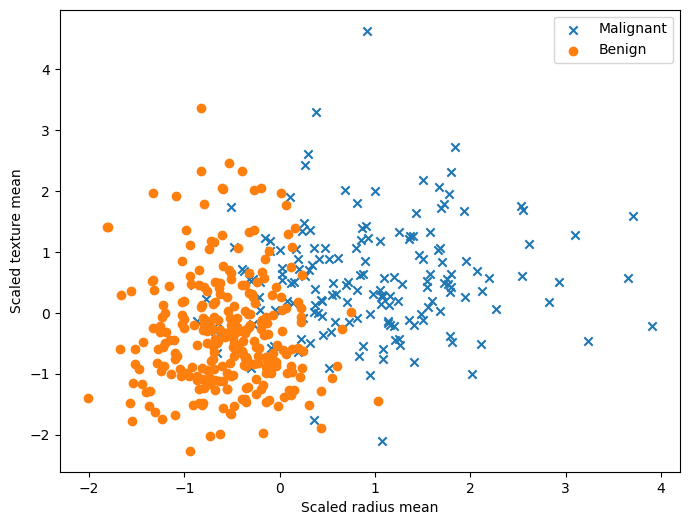

In [17]:
# =========================================
# Plotting the Data
# =========================================

# Malignant
malignant = y_train_np == 1

# Benign
benign = y_train_np == 0

plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_scaled[malignant, 0],
    X_train_scaled[malignant, 1],
    label="Malignant",
    marker="x"
)

plt.scatter(
    X_train_scaled[benign, 0],
    X_train_scaled[benign, 1],
    label="Benign",
    marker="o"
)

plt.xlabel("Scaled radius mean")
plt.ylabel("Scaled texture mean")

plt.legend()
plt.show()

In [20]:
# =========================================
# Define Sigmoid function
# =========================================

def sigmoid(z):
    g = 1 / (1 + np.exp(-z))
    return g

# Confirm if correct
print(sigmoid(0)) # sigmoid(0) should be 0.5

0.5


In [23]:
# =========================================
# Cost Function
# =========================================

def compute_cost(X, y, w, b):

    m = X.shape[0]
    total_cost = 0.0
    
    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb_i = sigmoid(z_i)
        total_cost += (
            -y[i] * np.log(f_wb_i)
            - (1 - y[i]) * np.log(1 - f_wb_i)
        )
    
    total_cost = total_cost / m
    return total_cost

In [24]:
m, n = X_train_scaled.shape

# Compute and display cost with w and b initialized to zeros
initial_w = np.zeros(n)
initial_b = 0.
cost = compute_cost(X_train_scaled, y_train_np, initial_w, initial_b)
print('Cost at initial w and b (zeros): {:.3f}'.format(cost))

Cost at initial w and b (zeros): 0.693


In [25]:
# =========================================
# Gradient for Logistic Regression
# =========================================

def compute_gradient(X, y, w, b):

    m, n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0.

    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i],w) + b)

        dj_db_i = f_wb_i - y[i]
        dj_db += dj_db_i     

        for j in range(n):
            dj_dw_ij = dj_db_i * X[i,j]
            dj_dw[j] += dj_dw_ij 
            
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_db, dj_dw

In [27]:
# Compute and display gradient with w and b initialized to zeros
initial_w = np.zeros(n)
initial_b = 0.

dj_db, dj_dw = compute_gradient(X_train_scaled, y_train_np, initial_w, initial_b)
print(f'dj_db at initial w and b (zeros): {dj_db}')
print(f'dj_dw at initial w and b (zeros): {dj_dw.tolist()}')

dj_db at initial w and b (zeros): 0.12637362637362637
dj_dw at initial w and b (zeros): [-0.35225915479617087, -0.20008316994031566]


In [28]:
# =========================================
# Train Model with Gradient Descent
# =========================================

def gradient_descent(
    X, 
    y, 
    w_in, 
    b_in, 
    cost_function, 
    gradient_function, 
    alpha, 
    num_iters
): 
    
    # Store cost and weights during training
    J_history = []
    w_history = []
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db, dj_dw = gradient_function(
            X, 
            y, 
            w_in, 
            b_in, 
        )   

        # Update Parameters using w, b, alpha and gradient
        w_in = w_in - alpha * dj_dw               
        b_in = b_in - alpha * dj_db              
       
        # Save cost J at each iteration
        cost =  cost_function(
            X, 
            y, 
            w_in, 
            b_in
        )
        J_history.append(cost)

        # Print cost every at intervals 10 times
        if i% math.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w_in)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w_in, b_in, J_history, w_history #return w and J,w history for graphing

In [35]:
# =========================================
# Initial Gradient Descent
# =========================================

initial_w = np.zeros(2)
initial_b = 0.0

# Initial gradient descent settings
iterations = 10000
alpha = 0.001

w,b, J_history,_ = gradient_descent(
    X_train_scaled,
    y_train_np, 
    initial_w, 
    initial_b,
    compute_cost, 
    compute_gradient, 
    alpha, 
    iterations
)

Iteration    0: Cost     0.69   
Iteration 1000: Cost     0.56   
Iteration 2000: Cost     0.48   
Iteration 3000: Cost     0.43   
Iteration 4000: Cost     0.40   
Iteration 5000: Cost     0.38   
Iteration 6000: Cost     0.36   
Iteration 7000: Cost     0.35   
Iteration 8000: Cost     0.34   
Iteration 9000: Cost     0.33   
Iteration 9999: Cost     0.32   


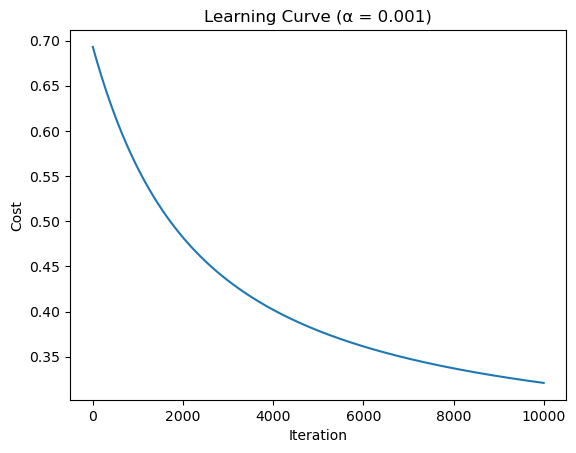

In [39]:
# =========================================
# Plot Learning Curve
# =========================================

plt.plot(J_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Learning Curve (α = 0.001)")
plt.show()

# Convergence is stable but relatively slow

In [41]:
# =========================================
# Gradient Descent with Increased Learning Rate
# =========================================

initial_w = np.zeros(2)
initial_b = 0.0

# Increase learning rate to accelerate convergence
iterations = 2000
alpha = 0.1

w,b, J_history,_ = gradient_descent(
    X_train_scaled,
    y_train_np, 
    initial_w, 
    initial_b, 
    compute_cost, 
    compute_gradient, 
    alpha, 
    iterations
)

Iteration    0: Cost     0.68   
Iteration  200: Cost     0.28   
Iteration  400: Cost     0.27   
Iteration  600: Cost     0.26   
Iteration  800: Cost     0.26   
Iteration 1000: Cost     0.26   
Iteration 1200: Cost     0.26   
Iteration 1400: Cost     0.26   
Iteration 1600: Cost     0.26   
Iteration 1800: Cost     0.26   
Iteration 1999: Cost     0.26   


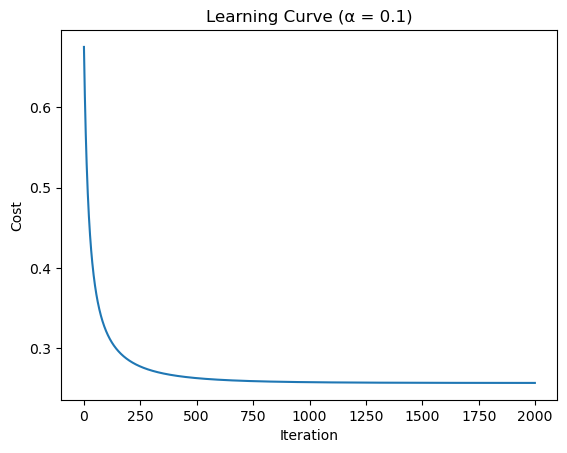

In [42]:
# =========================================
# Plot Learning Curve
# =========================================

plt.plot(J_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Learning Curve (α = 0.1)")
plt.show()

# Cost stabilizes before 2000 iterations, indicating convergence

In [43]:
# =========================================
# Plot Decision Boundary
# =========================================

def plot_decision_boundary(w, b, X, y):
    malignant = y == 1
    benign = y == 0

    plt.figure(figsize=(8, 6))

    plt.scatter(
        X[malignant, 0], 
        X[malignant, 1],
        marker="x", 
        label="Malignant"
    )

    plt.scatter(
        X[benign, 0], 
        X[benign, 1],
        marker="o", 
        label="Benign"
    )

    x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    x2 = -(w[0] * x1 + b) / w[1]

    plt.plot(x1, x2, label="Decision boundary")

    plt.xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

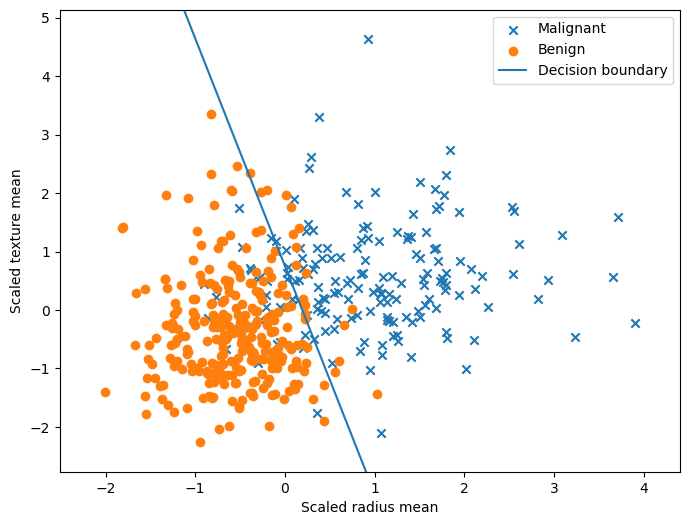

In [45]:
plot_decision_boundary(w, b, X_train_scaled, y_train_np)

plt.xlabel("Scaled radius mean")
plt.ylabel("Scaled texture mean")
plt.legend(loc="upper right")
plt.show()

In [47]:
# =========================================
# Evaluating Logistic Regression
# =========================================

def predict(X, w, b):
    m, n = X.shape
    p = np.zeros(m)

    for i in range(m):
        z_wb = 0
        for j in range(n):
            z_wb += w[j] * X[i][j]

        z_wb += b

        f_wb = sigmoid(z_wb)

        p[i] = 1 if f_wb >= 0.5 else 0
        
    return p 

In [50]:
# =========================================
# Evaluating Model Accuracy
# =========================================

# Compute accuracy on training set
p_train = predict(X_train_scaled, w, b)
train_accuracy = np.mean(p_train == y_train_np) * 100

print(f"Train Accuracy: {train_accuracy:.2f}%")

# Compute accuracy on test set
p_test = predict(X_test_scaled, w, b)
test_accuracy = np.mean(p_test == y_test_np) * 100

print(f"Test Accuracy: {test_accuracy:.2f}%")

Train Accuracy: 89.45%
Test Accuracy: 86.84%
